# **Datos del Estudiante**

Nombre: Odilón Nolf Sánchez

CI: 4189076

# **Clase 4 — Modelos Supervisados II: SVM y Redes Neuronales (MLP)**

**Objetivos**
- Comprender modelos no lineales potentes: SVM (kernels) y MLP (redes neuronales multicapa).
- Ver la formulación matemática esencial y las decisiones de optimización.
- Implementar y comparar SVM (RBF) y MLP con `scikit-learn`.
- Visualizar fronteras de decisión en datasets no lineales (moons, circles).
- Realizar ejercicios prácticos y análisis de hiperparámetros.


## **Imports y configuración inicial**

In [1]:
# Imports básicos
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# Crear carpeta para guardar figuras
os.makedirs('figures', exist_ok=True)


## **Funciones auxiliares: plot de frontera y utilidades**

Usa la función de explicar codigo. Explica con tus palabras para que sierve la función plot_decision_boundary.

In [2]:
def plot_decision_boundary(clf, X, y, ax=None, title=None, cmap='coolwarm', proba=False):
    """
    Dibuja la frontera de decisión de un clasificador entrenado.
    - clf: clasificador (debe tener predict o predict_proba/decision_function)
    - X: array (n_samples, 2)
    - y: etiquetas
    - ax: matplotlib axis opcional
    - proba: si True intenta usar predict_proba para contornos
    """
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
    y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    try:
        if proba and hasattr(clf, "predict_proba"):
            Z = clf.predict_proba(grid)[:,1]
            Z = Z.reshape(xx.shape)
            cs = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.4)
        else:
            Z = clf.predict(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    except Exception:
        # fallback: usar decision_function si existe
        if hasattr(clf, "decision_function"):
            Z = clf.decision_function(grid)
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z > 0, alpha=0.3, cmap=cmap)
        else:
            raise
    ax.scatter(X[:,0], X[:,1], c=y, s=30, edgecolor='k', cmap=cmap)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    if title:
        ax.set_title(title)

def save_figure(fig, fname):
    path = os.path.join('figures', fname)
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f"Saved {path}")


## **Generar datasets no lineales (moons y circles)**

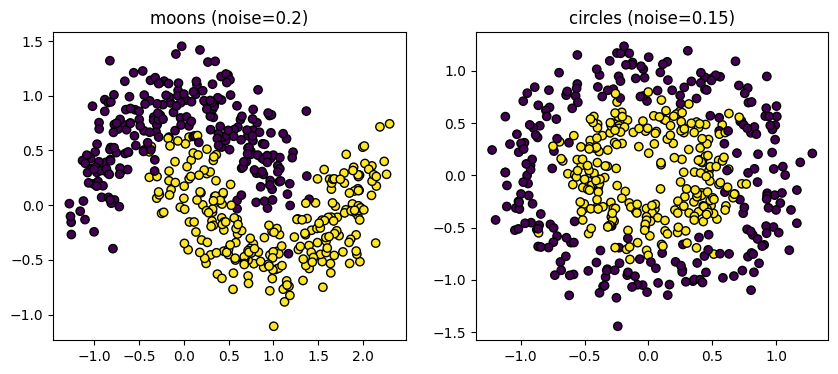

In [3]:
# Dataset: moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=0)

# Dataset: circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.15, factor=0.5, random_state=1)

# Mostrar ejemplos
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(X_moons[:,0], X_moons[:,1], c=y_moons, edgecolor='k')
axes[0].set_title('moons (noise=0.2)')
axes[1].scatter(X_circles[:,0], X_circles[:,1], c=y_circles, edgecolor='k')
axes[1].set_title('circles (noise=0.15)')
plt.show()


> Consulta en la notebookLM sobre las funciones make_moons, make_circles, make_classification y explica en que se diferencian:

## **Entrenamiento y visualización: moons (SVM vs MLP)**

Moons - SVM acc: 0.94
Moons - MLP acc: 0.9533333333333334
Saved figures/svm_moons_vs_mlp_moons.png


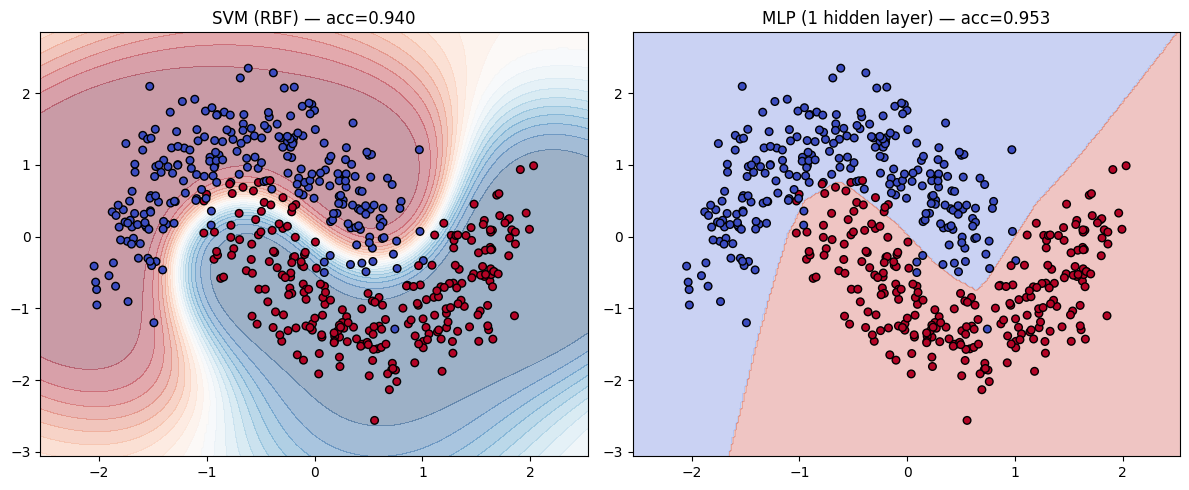

In [4]:
# Preparar datos (train/test + escalado)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)
scaler_m = StandardScaler().fit(X_train_m)
X_train_m_s = scaler_m.transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)
X_moons_s = scaler_m.transform(X_moons)

# Modelos
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_moons = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar
svm_rbf.fit(X_train_m_s, y_train_m)
mlp_moons.fit(X_train_m_s, y_train_m)

# Evaluar
pred_svm_m = svm_rbf.predict(X_test_m_s)
pred_mlp_m = mlp_moons.predict(X_test_m_s)
print("Moons - SVM acc:", accuracy_score(y_test_m, pred_svm_m))
print("Moons - MLP acc:", accuracy_score(y_test_m, pred_mlp_m))

# Plot y guardar
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=axes[0], title=f"SVM (RBF) — acc={accuracy_score(y_test_m, pred_svm_m):.3f}", proba=True)
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=axes[1], title=f"MLP (1 hidden layer) — acc={accuracy_score(y_test_m, pred_mlp_m):.3f}")
plt.tight_layout()
save_figure(fig, 'svm_moons_vs_mlp_moons.png')
plt.show()


> Respoden entre lineas

1.   Qué función cumple el parámetro C en SVC?
2.   Cómo afecta el hiperparametro degree al modelo de SVC?
3.   Qué otras funciones de activación permite la función MLPClassifier?
4.   Cómo afecta el solver sgd al MLPClassifier en su exactitud? Solicita ayuda al chatbot de la notebookLM para entender las diferencias en la exactitud al cambiar el solver de adam a sgd.  





## **Guardar modelos y artefactos**

Usa la función de explicar codigo y explica con tus palabras la utilidad de su implementación

In [5]:
joblib.dump(svm_rbf, 'figures/svm_moons_model.joblib')
joblib.dump(mlp_moons, 'figures/mlp_moons_model.joblib')
joblib.dump(scaler_m, 'figures/scaler_moons.joblib')

# Preparar datos (train/test + escalado) para circles
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.3, random_state=42)
scaler_c = StandardScaler().fit(X_train_c)
X_train_c_s = scaler_c.transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Modelos para circles
svm_rbf_c = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_circles = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

# Entrenar modelos para circles
svm_rbf_c.fit(X_train_c_s, y_train_c)
mlp_circles.fit(X_train_c_s, y_train_c)

joblib.dump(svm_rbf_c, 'figures/svm_circles_model.joblib')
joblib.dump(mlp_circles, 'figures/mlp_circles_model.joblib')
joblib.dump(scaler_c, 'figures/scaler_circles.joblib')

print("Modelos y scalers guardados en carpeta 'figures'.")

Modelos y scalers guardados en carpeta 'figures'.


## **Ejemplo de Carga y Uso de Modelos Guardados**

In [6]:
print('--- Ejemplo de Carga y Uso de Modelos Guardados ---\n')

# 1. Cargar el modelo y el scaler
loaded_svm_moons = joblib.load('figures/svm_moons_model.joblib')
loaded_scaler_moons = joblib.load('figures/scaler_moons.joblib')

print('Modelos y scalers cargados exitosamente.\n')

# 2. Generar un nuevo punto de datos para predecir (o tomar uno del conjunto de prueba)
# Usaremos un punto de X_test_m para demostrar la funcionalidad
new_data_point_original = X_test_m[0].reshape(1, -1) # reshape para que sea 2D

print(f'Punto de datos original para predecir: {new_data_point_original[0]}\n')

# 3. Escalar el nuevo punto de datos usando el scaler cargado
new_data_point_scaled = loaded_scaler_moons.transform(new_data_point_original)

print(f'Punto de datos escalado: {new_data_point_scaled[0]}\n')

# 4. Realizar una predicción con el modelo cargado
prediction = loaded_svm_moons.predict(new_data_point_scaled)

print(f'La predicción del modelo cargado para este punto es: {prediction[0]}\n')

# Para verificar, comparemos con la etiqueta real (si es conocida)
actual_label = y_test_m[0]
print(f'La etiqueta real (conocida) para este punto es: {actual_label}\n')

if prediction[0] == actual_label:
    print('¡La predicción coincide con la etiqueta real!')
else:
    print('La predicción NO coincide con la etiqueta real.')


--- Ejemplo de Carga y Uso de Modelos Guardados ---

Modelos y scalers cargados exitosamente.

Punto de datos original para predecir: [ 1.09250531 -0.37335468]

Punto de datos escalado: [ 0.65767012 -1.15397239]

La predicción del modelo cargado para este punto es: 1

La etiqueta real (conocida) para este punto es: 1

¡La predicción coincide con la etiqueta real!


## **Visualizaciones separadas (guardar SVM y MLP por separado)**

In [7]:
# Si prefieres archivos separados por modelo, generarlos así:

X_circles_s = scaler_c.transform(X_circles)

# Moons: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf, X_moons_s, y_moons, ax=ax, title="SVM (RBF) — moons", proba=True)
save_figure(fig, 'svm_moons.png')
plt.close(fig)

# Moons: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_moons, X_moons_s, y_moons, ax=ax, title="MLP (1 hidden layer) — moons")
save_figure(fig, 'mlp_moons.png')
plt.close(fig)

# Circles: SVM
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(svm_rbf_c, X_circles_s, y_circles, ax=ax, title="SVM (RBF) — circles", proba=True)
save_figure(fig, 'svm_circles.png')
plt.close(fig)

# Circles: MLP
fig, ax = plt.subplots(1,1,figsize=(6,5))
plot_decision_boundary(mlp_circles, X_circles_s, y_circles, ax=ax, title="MLP (2 hidden layers) — circles")
save_figure(fig, 'mlp_circles.png')
plt.close(fig)


Saved figures/svm_moons.png
Saved figures/mlp_moons.png
Saved figures/svm_circles.png
Saved figures/mlp_circles.png


## **Análisis de sensibilidad a hiperparámetros**

In [8]:
# Ejemplo: variar C y gamma en SVM (moons) y observar accuracy en test
from itertools import product

Cs = [0.1, 1, 10]
gammas = ['scale', 0.5, 1.0]
results = []

for C, g in product(Cs, gammas):
    clf = SVC(kernel='rbf', C=C, gamma=g, random_state=42)
    clf.fit(X_train_m_s, y_train_m)
    acc = accuracy_score(y_test_m, clf.predict(X_test_m_s))
    results.append((C, g, acc))

import pandas as pd
df_res = pd.DataFrame(results, columns=['C','gamma','acc'])
print(df_res.pivot(index='C', columns='gamma', values='acc'))


gamma       0.5       1.0     scale
C                                  
0.1    0.906667  0.933333  0.906667
1.0    0.940000  0.960000  0.940000
10.0   0.966667  0.966667  0.966667


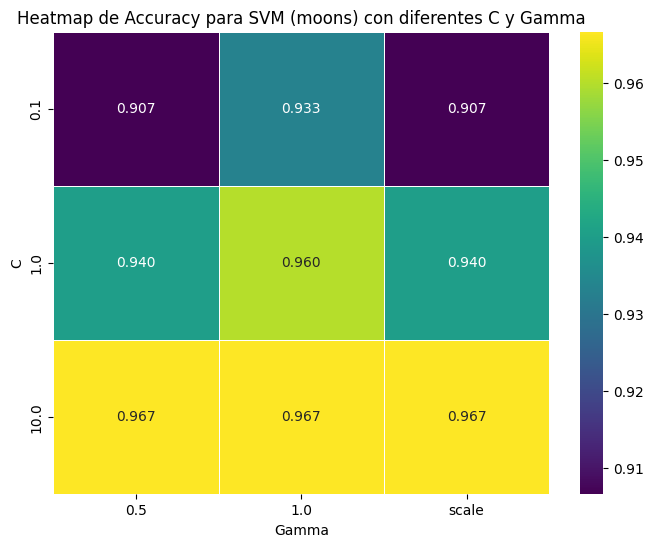

In [9]:
import seaborn as sns

# Preparar los datos para el heatmap
# El dataframe df_res ya tiene los resultados de la sensibilidad
# lo pivotamos como se hizo antes para el print
heatmap_data = df_res.pivot(index='C', columns='gamma', values='acc')

# Crear el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".3f", linewidths=.5)
plt.title('Heatmap de Accuracy para SVM (moons) con diferentes C y Gamma')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()


> Interpreta los resultados del analisis de sensibilidad a hiperparámetros:

# **Ejercicios prácticos**

1. **Explorar hiperparámetros SVM**
   - En el dataset `moons`, haga una búsqueda en cuadrícula (GridSearchCV) sobre `C` y `gamma`.
   - Reporte la mejor combinación y compare la frontera resultante con la frontera por defecto.

2. **Arquitectura MLP**
   - En `circles`, pruebe distintas arquitecturas: una capa oculta con 50, 100, 200 unidades; dos capas con (50,50), (100,50), (100,100).
   - Compare accuracy y tiempos de entrenamiento. ¿Qué arquitectura generaliza mejor?

3. **Regularización y early stopping**
   - Active `early_stopping=True` en `MLPClassifier` y compare la convergencia y la generalización.
   - Añada `alpha` (regularización L2) y observe su efecto.

4. **Visualización y PCA**
   - Si dispone de un dataset con más de 2 atributos, aplique PCA a 2 componentes y visualice las fronteras de decisión de SVM y MLP en el espacio proyectado.

5. **Comparación cuantitativa**
   - Para ambos datasets, calcule matriz de confusión y reporte precision/recall/F1 para SVM y MLP.
   - Discuta en qué regiones del espacio cada modelo comete más errores.

6. **Actividad avanzada (opcional)**
   - Implementar un perceptrón multicapa simple (forward + backprop) desde cero para un dataset 2D y comparar su frontera con `MLPClassifier`.


## **Ejercicio 1: Hiperparámetros SVM en `moons`**


In [10]:
from sklearn.model_selection import GridSearchCV

# Define el rango de hiperparámetros para la búsqueda
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 0.5, 1, 'scale'],
    'kernel': ['rbf'] # Aseguramos que sea RBF ya que la pregunta es sobre C y gamma
}

# Inicializa el clasificador SVM
svc = SVC(random_state=42)

# Configura GridSearchCV
# cv=5 significa validación cruzada de 5 pliegues
# scoring='accuracy' indica que queremos optimizar la precisión
# n_jobs=-1 utiliza todos los procesadores disponibles
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Realiza la búsqueda en cuadrícula en los datos de entrenamiento escalados
grid_search.fit(X_train_m_s, y_train_m)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 0.5, 1, 'scale'],
                         'kernel': ['rbf']},
             scoring='accuracy', verbose=1)

In [11]:
# Reporta la mejor combinación de hiperparámetros y su rendimiento
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor score de validación cruzada (accuracy):", grid_search.best_score_)

# El mejor estimador entrenado
best_svm = grid_search.best_estimator_

# Evalúa el mejor modelo en el conjunto de prueba
pred_best_svm_m = best_svm.predict(X_test_m_s)
acc_best_svm = accuracy_score(y_test_m, pred_best_svm_m)
print(f"Accuracy del mejor SVM en el conjunto de prueba: {acc_best_svm:.3f}")

Mejores hiperparámetros encontrados: {'C': 100, 'gamma': 0.5, 'kernel': 'rbf'}
Mejor score de validación cruzada (accuracy): 0.9657142857142856
Accuracy del mejor SVM en el conjunto de prueba: 0.953


Saved figures/svm_moons_default_vs_gridsearch.png


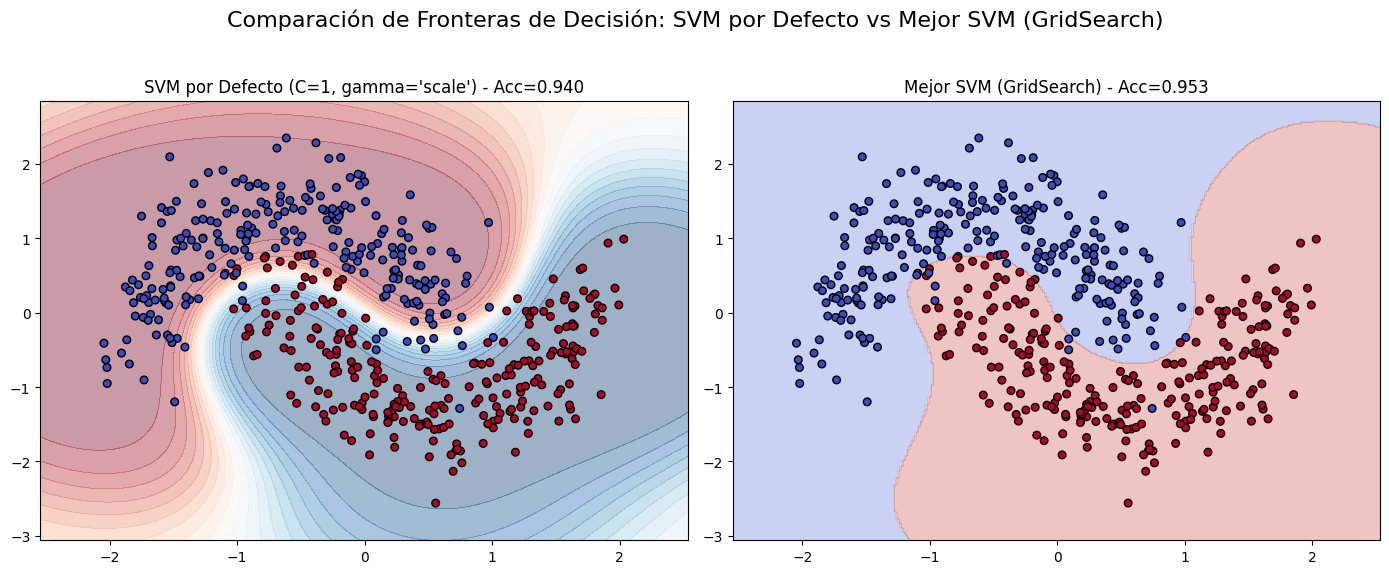

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Frontera de decisión del SVM por defecto (del código anterior)
# Recreamos el SVM por defecto para asegurar la comparación
default_svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
default_svm.fit(X_train_m_s, y_train_m)
pred_default_svm = default_svm.predict(X_test_m_s)
acc_default_svm = accuracy_score(y_test_m, pred_default_svm)

plot_decision_boundary(default_svm, X_moons_s, y_moons, ax=axes[0],
                       title=f"SVM por Defecto (C=1, gamma='scale') - Acc={acc_default_svm:.3f}", proba=True)

# 2. Frontera de decisión del mejor SVM encontrado por GridSearchCV
plot_decision_boundary(best_svm, X_moons_s, y_moons, ax=axes[1],
                       title=f"Mejor SVM (GridSearch) - Acc={acc_best_svm:.3f}", proba=True)

plt.suptitle('Comparación de Fronteras de Decisión: SVM por Defecto vs Mejor SVM (GridSearch)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_figure(fig, 'svm_moons_default_vs_gridsearch.png')
plt.show()

## **Ejercicio 2: Arquitectura MLP en `circles`**

Vamos a probar diferentes arquitecturas para el `MLPClassifier` en el dataset `circles` y comparar su rendimiento.


Entrenando MLP con arquitectura: 1 capa (50 unidades) (50,)

Entrenando MLP con arquitectura: 1 capa (100 unidades) (100,)

Entrenando MLP con arquitectura: 1 capa (200 unidades) (200,)

Entrenando MLP con arquitectura: 2 capas (50,50 unidades) (50, 50)

Entrenando MLP con arquitectura: 2 capas (100,50 unidades) (100, 50)

Entrenando MLP con arquitectura: 2 capas (100,100 unidades) (100, 100)

Resultados de las arquitecturas MLP:
                 Arquitectura Configuración  Accuracy  \
0        1 capa (50 unidades)         (50,)  0.900000   
1       1 capa (100 unidades)        (100,)  0.906667   
2       1 capa (200 unidades)        (200,)  0.913333   
3    2 capas (50,50 unidades)      (50, 50)  0.906667   
4   2 capas (100,50 unidades)     (100, 50)  0.893333   
5  2 capas (100,100 unidades)    (100, 100)  0.906667   

   Tiempo de Entrenamiento (s)  
0                     0.669684  
1                     0.872242  
2                     3.003374  
3                     1.240272  


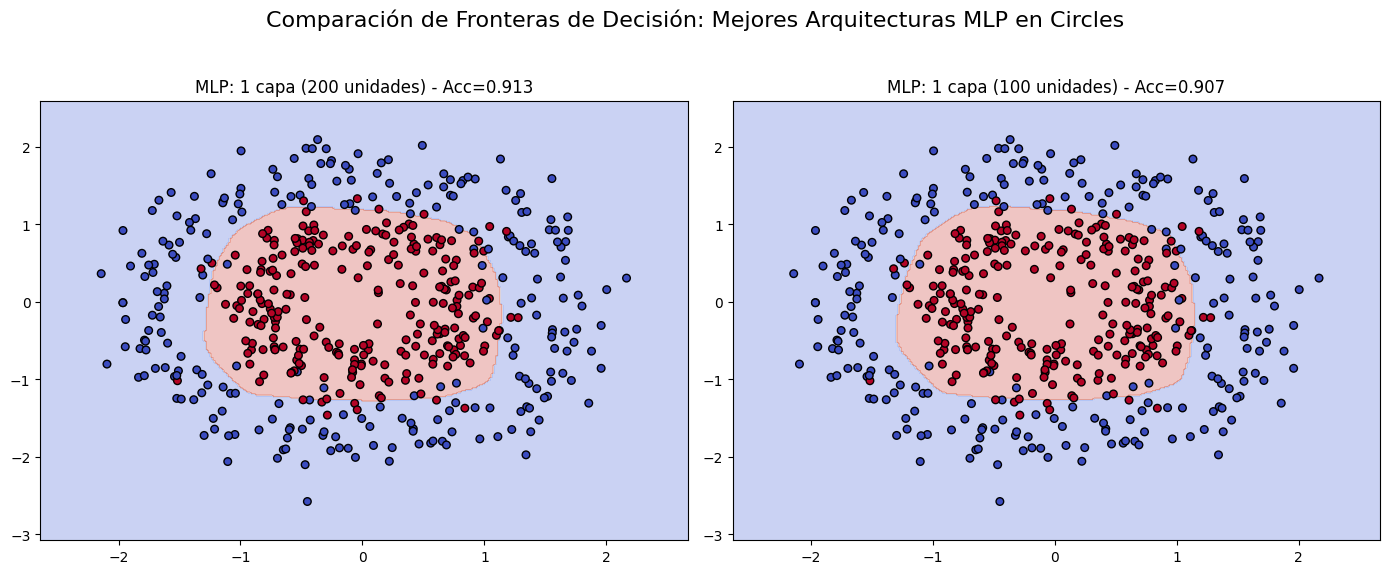

In [13]:
mlp_architectures = {
    "1 capa (50 unidades)": (50,),
    "1 capa (100 unidades)": (100,),
    "1 capa (200 unidades)": (200,),
    "2 capas (50,50 unidades)": (50, 50),
    "2 capas (100,50 unidades)": (100, 50),
    "2 capas (100,100 unidades)": (100, 100)
}

results_mlp_arch = []

for name, architecture in mlp_architectures.items():
    print(f"\nEntrenando MLP con arquitectura: {name} {architecture}")
    mlp_model = MLPClassifier(hidden_layer_sizes=architecture,
                              activation='relu',
                              solver='adam',
                              max_iter=1000,
                              random_state=42,
                              verbose=False) # Desactivar verbose para no saturar la salida

    # Entrenar y medir tiempo
    import time
    start_time = time.time()
    mlp_model.fit(X_train_c_s, y_train_c)
    end_time = time.time()
    training_time = end_time - start_time

    # Evaluar
    predictions = mlp_model.predict(X_test_c_s)
    accuracy = accuracy_score(y_test_c, predictions)

    results_mlp_arch.append({
        'Arquitectura': name,
        'Configuración': architecture,
        'Accuracy': accuracy,
        'Tiempo de Entrenamiento (s)': training_time
    })

# Mostrar resultados
import pandas as pd
df_mlp_arch_results = pd.DataFrame(results_mlp_arch)
print("\nResultados de las arquitecturas MLP:")
print(df_mlp_arch_results)

# Visualizar algunas fronteras de decisión de las mejores arquitecturas
# Elegir las 2 mejores por accuracy (o algunas representativas)
sorted_results = df_mlp_arch_results.sort_values(by='Accuracy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (idx, row) in enumerate(sorted_results.head(2).iterrows()):
    best_arch_name = row['Arquitectura']
    best_arch_config = row['Configuración']
    best_arch_accuracy = row['Accuracy']

    # Re-entrenar el modelo para la visualización si es necesario (o tomar el ya entrenado si se guardó)
    # Por simplicidad, re-entrenamos para la visualización o usamos un modelo ya entrenado si existe en el ámbito
    # Aquí, recuperaremos el modelo entrenado del bucle o lo re-entrenaremos
    mlp_model_viz = MLPClassifier(hidden_layer_sizes=best_arch_config,
                                  activation='relu',
                                  solver='adam',
                                  max_iter=1000,
                                  random_state=42)
    mlp_model_viz.fit(X_train_c_s, y_train_c)

    plot_decision_boundary(mlp_model_viz, X_circles_s, y_circles, ax=axes[i],
                           title=f"MLP: {best_arch_name} - Acc={best_arch_accuracy:.3f}")

plt.suptitle('Comparación de Fronteras de Decisión: Mejores Arquitecturas MLP en Circles', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_figure(fig, 'mlp_circles_architectures_comparison.png')
plt.show()

## **Ejercicio 3: Regularización y early stopping**


--- Explorando Early Stopping y Regularización (MLP en circles) ---

Entrenando MLP con Early Stopping...
Entrenando MLP con Early Stopping y Regularización L2 (alpha=0.01)...

Resultados de MLP con Early Stopping y Regularización:


,Modelo,Accuracy,Tiempo de Entrenamiento (s),Número de Iteraciones,Pérdida Final
0,MLP con Early Stopping,0.9,0.199325,44,0.282963
1,MLP con Early Stopping + L2 (alpha=0.01),0.9,0.191161,45,0.275956


Saved figures/mlp_circles_early_stopping_regularization.png


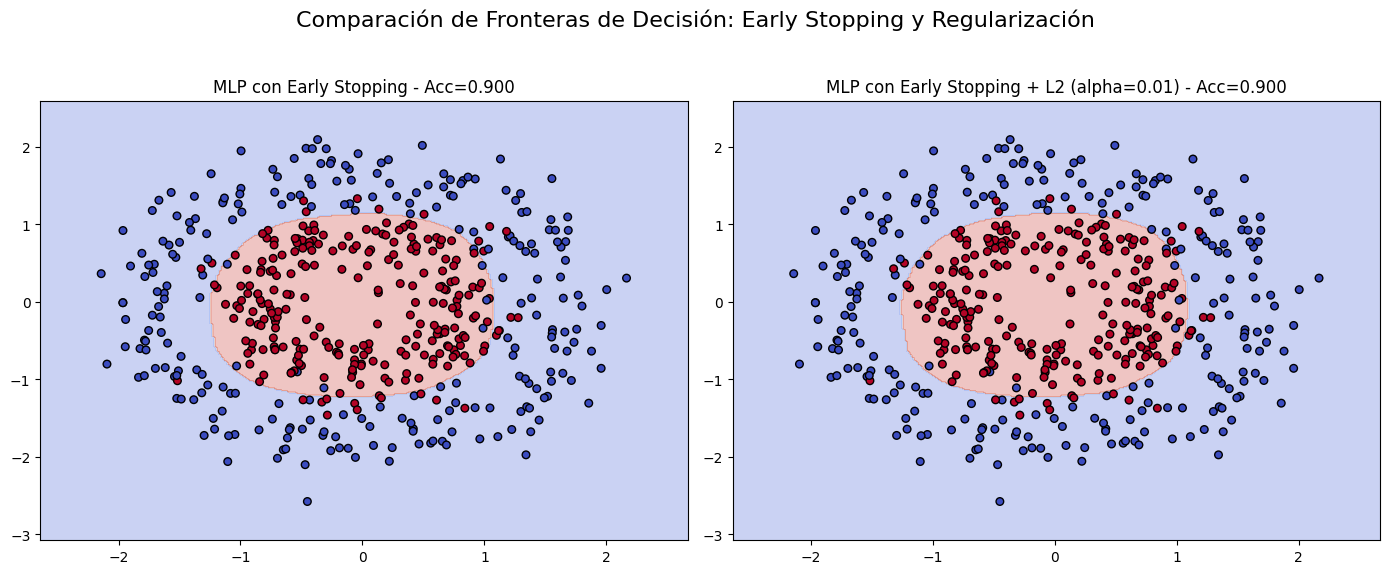

In [14]:
print("\n--- Explorando Early Stopping y Regularización (MLP en circles) ---\n")

results_reg_es = []

# 1. MLP con Early Stopping
print("Entrenando MLP con Early Stopping...")
mlp_es = MLPClassifier(hidden_layer_sizes=(100, 50),
                         activation='relu',
                         solver='adam',
                         max_iter=1000,
                         random_state=42,
                         early_stopping=True,
                         validation_fraction=0.1,
                         n_iter_no_change=10,
                         verbose=False) # Desactivar verbose para no saturar

start_time_es = time.time()
mlp_es.fit(X_train_c_s, y_train_c)
end_time_es = time.time()
training_time_es = end_time_es - start_time_es

predictions_es = mlp_es.predict(X_test_c_s)
accuracy_es = accuracy_score(y_test_c, predictions_es)

results_reg_es.append({
    'Modelo': 'MLP con Early Stopping',
    'Accuracy': accuracy_es,
    'Tiempo de Entrenamiento (s)': training_time_es,
    'Número de Iteraciones': mlp_es.n_iter_,
    'Pérdida Final': mlp_es.loss_
})


# 2. MLP con Early Stopping y Regularización L2 (alpha)
print("Entrenando MLP con Early Stopping y Regularización L2 (alpha=0.01)...")
mlp_es_reg = MLPClassifier(hidden_layer_sizes=(100, 50),
                             activation='relu',
                             solver='adam',
                             max_iter=1000,
                             random_state=42,
                             early_stopping=True,
                             validation_fraction=0.1,
                             n_iter_no_change=10,
                             alpha=0.01, # Regularización L2
                             verbose=False)

start_time_es_reg = time.time()
mlp_es_reg.fit(X_train_c_s, y_train_c)
end_time_es_reg = time.time()
training_time_es_reg = end_time_es_reg - start_time_es_reg

predictions_es_reg = mlp_es_reg.predict(X_test_c_s)
accuracy_es_reg = accuracy_score(y_test_c, predictions_es_reg)

results_reg_es.append({
    'Modelo': 'MLP con Early Stopping + L2 (alpha=0.01)',
    'Accuracy': accuracy_es_reg,
    'Tiempo de Entrenamiento (s)': training_time_es_reg,
    'Número de Iteraciones': mlp_es_reg.n_iter_,
    'Pérdida Final': mlp_es_reg.loss_
})

# Mostrar resultados
df_reg_es_results = pd.DataFrame(results_reg_es)
print("\nResultados de MLP con Early Stopping y Regularización:")
display(df_reg_es_results)

# Visualizar fronteras de decisión
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(mlp_es, X_circles_s, y_circles, ax=axes[0],
                       title=f"MLP con Early Stopping - Acc={accuracy_es:.3f}")

plot_decision_boundary(mlp_es_reg, X_circles_s, y_circles, ax=axes[1],
                       title=f"MLP con Early Stopping + L2 (alpha=0.01) - Acc={accuracy_es_reg:.3f}")

plt.suptitle('Comparación de Fronteras de Decisión: Early Stopping y Regularización', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_figure(fig, 'mlp_circles_early_stopping_regularization.png')
plt.show()

## **Ejercicio 4: Visualización y PCA**

Para el Ejercicio 4, que pide aplicar PCA y visualizar fronteras de decisión en un espacio proyectado a 2 componentes, el dataset actual no posee **más de 2 atributos**.

Los datasets `moons` y `circles` que hemos estado utilizando tienen inherentemente solo 2 dimensiones. Aplicar PCA a estos datasets no reduciría la dimensionalidad de manera significativa (ya están en 2D), por lo que no cumpliría el propósito del ejercicio de "proyectar a 2 componentes" un dataset de mayor dimensión.

**Propuesta:** Generar dataset sintético para PCA con 5 características para poder demostrar el uso de PCA en este contexto y luego visualizar las fronteras de decisión.

### **Generación de Dataset Sintético para PCA (5 características)**

Shape del dataset sintético original: (500, 5)
Shape del dataset después de PCA: (500, 2)

Accuracy SVM en espacio PCA: 0.740
Accuracy MLP en espacio PCA: 0.760
Saved figures/pca_svm_mlp_synthetic_dataset.png


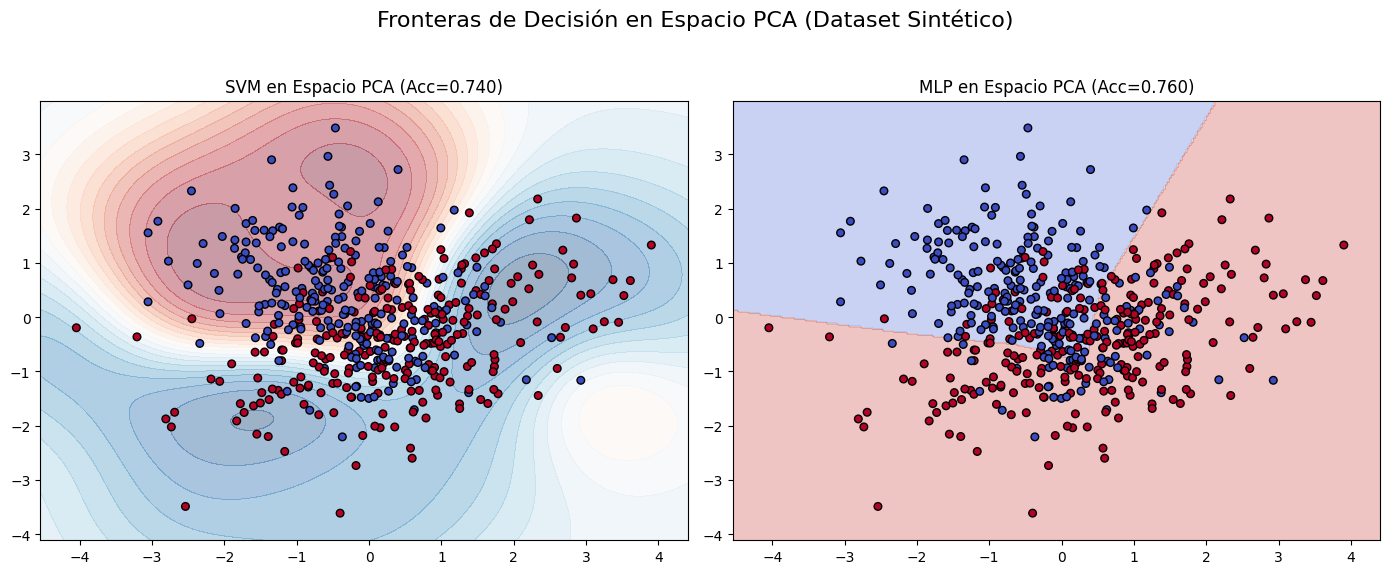

In [16]:
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# Generar un dataset sintético con 5 características
X_synth, y_synth = make_classification(n_samples=500, n_features=5, n_informative=3, n_redundant=0, n_clusters_per_class=1, random_state=42)

print(f"Shape del dataset sintético original: {X_synth.shape}")

# Dividir el dataset en entrenamiento y prueba
X_train_synth, X_test_synth, y_train_synth, y_test_synth = train_test_split(X_synth, y_synth, test_size=0.3, random_state=42)

# Escalar las características
scaler_synth = StandardScaler()
X_train_synth_s = scaler_synth.fit_transform(X_train_synth)
X_test_synth_s = scaler_synth.transform(X_test_synth)
X_synth_s = scaler_synth.transform(X_synth)

# Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_synth_s)
X_test_pca = pca.transform(X_test_synth_s)
X_synth_pca = pca.transform(X_synth_s)

print(f"Shape del dataset después de PCA: {X_synth_pca.shape}")

# Entrenar SVM y MLP en el espacio PCA reducido
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
mlp_pca = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=1000, random_state=42)

svm_pca.fit(X_train_pca, y_train_synth)
mlp_pca.fit(X_train_pca, y_train_synth)

# Evaluar modelos en el espacio PCA
acc_svm_pca = accuracy_score(y_test_synth, svm_pca.predict(X_test_pca))
acc_mlp_pca = accuracy_score(y_test_synth, mlp_pca.predict(X_test_pca))

print(f"\nAccuracy SVM en espacio PCA: {acc_svm_pca:.3f}")
print(f"Accuracy MLP en espacio PCA: {acc_mlp_pca:.3f}")

# Visualizar fronteras de decisión en el espacio PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(svm_pca, X_synth_pca, y_synth, ax=axes[0],
                       title=f"SVM en Espacio PCA (Acc={acc_svm_pca:.3f})", proba=True)

plot_decision_boundary(mlp_pca, X_synth_pca, y_synth, ax=axes[1],
                       title=f"MLP en Espacio PCA (Acc={acc_mlp_pca:.3f})")

plt.suptitle('Fronteras de Decisión en Espacio PCA (Dataset Sintético)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_figure(fig, 'pca_svm_mlp_synthetic_dataset.png')
plt.show()

## **Ejercicio 5: Comparación Cuantitativa**

En este ejercicio, realizaremos una comparación cuantitativa de los modelos SVM y MLP utilizando la matriz de confusión y métricas de clasificación como precisión, recall y F1-score para ambos datasets ('moons' y 'circles').

### **5.1 Métricas de Clasificación para el dataset `moons`**

In [17]:
# SVM en 'moons'
print("--- SVM en dataset 'moons' ---")
print("Matriz de Confusión:")
print(confusion_matrix(y_test_m, pred_svm_m))
print("\nReporte de Clasificación:")
print(classification_report(y_test_m, pred_svm_m))

# MLP en 'moons'
print("\n--- MLP en dataset 'moons' ---")
print("Matriz de Confusión:")
print(confusion_matrix(y_test_m, pred_mlp_m))
print("\nReporte de Clasificación:")
print(classification_report(y_test_m, pred_mlp_m))

--- SVM en dataset 'moons' ---
Matriz de Confusión:
[[74  3]
 [ 6 67]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        77
           1       0.96      0.92      0.94        73

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150


--- MLP en dataset 'moons' ---
Matriz de Confusión:
[[75  2]
 [ 5 68]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        77
           1       0.97      0.93      0.95        73

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



### **5.2 Métricas de Clasificación para el dataset `circles`**

Para el dataset 'circles', usaremos los modelos entrenados en el Ejercicio 3 para el MLP (early stopping y regularización L2) y el SVM por defecto entrenado en la sección inicial.

In [18]:
# Preparar datos para circles (usando los escalados X_test_c_s)

# SVM en 'circles' (usando el modelo svm_rbf_c previamente entrenado)
print("--- SVM en dataset 'circles' ---")
pred_svm_c = svm_rbf_c.predict(X_test_c_s)
print("Matriz de Confusión:")
print(confusion_matrix(y_test_c, pred_svm_c))
print("\nReporte de Clasificación:")
print(classification_report(y_test_c, pred_svm_c))

# MLP en 'circles' (usando el mejor modelo de early stopping + L2 del Ejercicio 3)
print("\n--- MLP con Early Stopping + L2 en dataset 'circles' ---")
# predictions_es_reg ya contiene las predicciones del mejor MLP del Ejercicio 3
print("Matriz de Confusión:")
print(confusion_matrix(y_test_c, predictions_es_reg))
print("\nReporte de Clasificación:")
print(classification_report(y_test_c, predictions_es_reg))

--- SVM en dataset 'circles' ---
Matriz de Confusión:
[[65  5]
 [ 9 71]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        70
           1       0.93      0.89      0.91        80

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150


--- MLP con Early Stopping + L2 en dataset 'circles' ---
Matriz de Confusión:
[[68  2]
 [13 67]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        70
           1       0.97      0.84      0.90        80

    accuracy                           0.90       150
   macro avg       0.91      0.90      0.90       150
weighted avg       0.91      0.90      0.90       150



#### **Regiones del espacio cada modelo comete más errores.**
Para el conjunto de datos **'moons'**:

Tanto los modelos **SVM** como **MLP** tuvieron un desempeño muy bueno, con alta precisión (**SVM: 0.94**, **MLP: 0.95**). Sus errores (**Falsos Positivos** y **Falsos Negativos**) fueron muy pocos y probablemente ocurrieron en la estrecha región de superposición donde las dos formas de “luna” están más próximas. El modelo **MLP** mostró una capacidad ligeramente mejor para delimitar esta frontera compleja, con marginalmente menos errores.

Para el conjunto de datos **'circles'**:

### SVM
Alcanzó una precisión de **0.91**. Mostró un desempeño relativamente equilibrado en términos de **precisión** y **recall** para ambas clases. Sus errores (**5 Falsos Positivos**, **9 Falsos Negativos**) sugieren que las clasificaciones incorrectas ocurrieron principalmente en la zona límite entre los círculos interno y externo. Fue ligeramente más propenso a clasificar erróneamente puntos del círculo interno como si pertenecieran al externo (**Falsos Negativos**).

### MLP con Early Stopping + L2
También alcanzó una precisión de **0.90**. Este modelo presentó un compromiso en sus patrones de error: muy pocos **Falsos Positivos (2)**, lo que indica que fue muy bueno evitando clasificar puntos del círculo externo como si fueran del interno. Sin embargo, tuvo un mayor número de **Falsos Negativos (13)**, lo que significa que fue más propenso a clasificar puntos del círculo interno como si fueran del externo. Esto sugiere que su frontera de decisión pudo haber sido ligeramente más agresiva al delimitar la clase externa, a costa de algunos puntos de la clase interna.

En esencia, para ambos conjuntos de datos, los errores se concentran en las regiones donde las clases son difíciles de separar, ya sea debido a su proximidad inherente o al ruido presente en los datos. El tipo de modelo (**SVM vs. MLP**) y sus hiperparámetros específicos influyen en cómo se trazan estas fronteras y, en consecuencia, en el equilibrio entre **Falsos Positivos** y **Falsos Negativos**.

# **Recursos y lecturas recomendadas**

- Cristianini, N. & Shawe-Taylor, J. — *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*.
- Goodfellow, I., Bengio, Y., Courville, A. — *Deep Learning* (capítulos introductorios sobre MLP y optimización).
- Documentación scikit-learn: `SVC`, `MLPClassifier`, `GridSearchCV`.
- Notebooks de ejemplo en la galería de scikit-learn (datasets y visualizaciones).


# Rúbrica de Evaluación

| Criterio | Descripción | Puntos |
|---|---:|---:|
| Implementación correcta | Código que entrena SVM y MLP según instrucciones y produce resultados reproducibles | **30** |
| Visualizaciones | Fronteras de decisión claras, bien etiquetadas y guardadas como PNG | **20** |
| Análisis de resultados | Interpretación de accuracy, matriz de confusión y discusión de diferencias entre modelos | **15** |
| Experimentos de hiperparámetros | Búsqueda/variación de hiperparámetros y resumen de hallazgos (tablas/plots) | **10** |
| Calidad del código | Legibilidad, comentarios, uso de funciones y buenas prácticas (scaling, seed) | **10** |
| Reproducibilidad y artefactos | Modelos y scalers guardados; instrucciones claras para reproducir y exportar figuras | **10** |
| Entrega y presentación | Notebook ordenado, celdas ejecutables, resultados exportados y breve informe final | **5** |

**Total: 100 puntos**

**Escala sugerida**
- 90–100: Excelente
- 75–89: Bueno
- 60–74: Aceptable
- <60: Insuficiente

